# Complex Numbers — Lecture 8
## De Moivre's Theorem · Integer vs Fractional Powers · $n$-th Roots of Unity and Their Properties

**Source:** [Complex Numbers 08 | De-Moivre's Theorem & n-th roots of Unity | Class 11 | JEE](https://youtu.be/mk8RrYW_4v4), Physics Wallah (Class 11), about 65 min

**Prerequisite:** Lecture 5 (polar and Euler form), Lecture 7 (cube roots of unity and their properties). The lecturer insists on Lecture 7 first: *"without it, this lecture won't land properly."*

### What this lecture covers
1. **De Moivre's theorem:** $(\cos\theta + i\sin\theta)^n = \cos n\theta + i\sin n\theta$, which is the **only** value when $n$ is an integer, and **one of the values** when $n$ is a fraction
2. Integer power example: $(\sqrt3 + i)^5$
3. **Fractional powers: the 4-step recipe** for all $q$ values of $z^{p/q}$, with the example $(\sqrt3 + i)^{1/5}$
4. **$n$-th roots of unity** $1^{1/n} = e^{i\,2k\pi/n}$, $k = 0, \dots, n - 1$, written $1, \alpha, \alpha^2, \dots, \alpha^{n-1}$
5. **Properties:**
   - GP (and arguments in AP)
   - sum $= 0$
   - $\alpha_k^n = 1$
   - unit circle, regular $n$-gon
   - $\sum\alpha_k^p \in \{0, n\}$
   - the factorisation $x^n - 1 = \prod(x - \alpha_k)$, product of roots $= (-1)^{n-1}$, and $\prod_{k \ge 1}(1 - \alpha_k) = n$

Next (and last) lecture of the chapter: **rotation** of complex numbers.

Sections marked *(extra)* go beyond what was said in the lecture.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
from matplotlib import animation
from IPython.display import HTML

# Same look as Lectures 1–7
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
    "animation.embed_limit": 30,
})
rng = np.random.default_rng(8)

def argand(ax, lim=2.5, ticks=1):
    # Draw the complex plane: real axis horizontal, imaginary axis vertical
    ax.axhline(0, color=INK2, lw=1); ax.axvline(0, color=INK2, lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    t = np.arange(ticks, lim, ticks); t = np.r_[-t[::-1], 0, t]
    ax.set_xticks(t)
    ax.set_yticks(t, ["0" if v == 0 else "i" if v == 1 else "−i" if v == -1 else f"{v:g}i".replace("-", "−") for v in t])
    ax.set_xlabel("Re"); ax.set_ylabel("Im")

def arrow(ax, z0, z1, color, lw=2, ls="-"):
    z0, z1 = complex(z0), complex(z1)
    ax.annotate("", (z1.real, z1.imag), (z0.real, z0.imag),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, ls=ls, mutation_scale=14, shrinkA=0, shrinkB=0))

def circle(ax, r=1.0, color=GRID, lw=1.5, ls="-"):
    c = np.linspace(0, 2*np.pi, 300); ax.plot(r*np.cos(c), r*np.sin(c), color=color, lw=lw, ls=ls)

def pi_str(x, den=60):
    # Pretty-print a rational multiple of π, e.g. "13π/30"
    f = Fraction(x/np.pi).limit_denominator(den)
    if f == 0: return "0"
    s = "−" if f < 0 else ""; f = abs(f)
    num = "" if f.numerator == 1 else str(f.numerator)
    return f"{s}{num}π" + ("" if f.denominator == 1 else f"/{f.denominator}")

def unity_roots(n):
    return np.exp(2j*np.pi*np.arange(n)/n)
print("ready")

ready


---
## 1. De Moivre's Theorem

**Statement (in two parts, as in the lecture):**

**(a) Integer power.** If $n \in \mathbb{Z}$,
$$\boxed{(\cos\theta + i\sin\theta)^n = \cos n\theta + i\sin n\theta}$$
and this is the **only** value.

**(b) Fractional power.** If $n$ is a **non-integral rational** number, then $\cos n\theta + i\sin n\theta$ is **one of the values** of $(\cos\theta + i\sin\theta)^n$. There are several, and the recipe below finds all of them.

**De Moivre's headline:** raise any complex number to an integer power and you get **one** answer. Raise it to a fractional power $\frac{p}{q}$ in lowest terms and you get **$q$ answers**, as many as the denominator. For example, $z^{3}$ has one value and $z^{3/4}$ has four.

### Why (a) holds (via Euler, Lecture 5)
$$(\cos\theta + i\sin\theta)^n = \left(e^{i\theta}\right)^n = e^{in\theta} = \cos n\theta + i\sin n\theta$$
The last step is just Euler's formula with angle $n\theta$. In words, **the power comes down and multiplies the angle.**

*The real glamour isn't that $(\operatorname{cis}\theta)^n = \operatorname{cis} n\theta$. It's that for fractional $n$ there are **other** values too.*

In [2]:
th = rng.uniform(-np.pi, np.pi, 100_000)
for n in [2, 5, -3, 12]:
    ok = np.isclose((np.cos(th) + 1j*np.sin(th))**n, np.cos(n*th) + 1j*np.sin(n*th)).mean()*100
    print(f"n = {n:>3}:  (cos θ + i sin θ)^n = cos nθ + i sin nθ  holds on {ok:.2f}% of 100,000 θ")

n =   2:  (cos θ + i sin θ)^n = cos nθ + i sin nθ  holds on 100.00% of 100,000 θ
n =   5:  (cos θ + i sin θ)^n = cos nθ + i sin nθ  holds on 100.00% of 100,000 θ
n =  -3:  (cos θ + i sin θ)^n = cos nθ + i sin nθ  holds on 100.00% of 100,000 θ
n =  12:  (cos θ + i sin θ)^n = cos nθ + i sin nθ  holds on 100.00% of 100,000 θ


---
## 2. Integer Power: $(\sqrt3 + i)^5$

**Step 1: polar form.** $|\sqrt3 + i| = 2$, and $\arg = \frac{\pi}{6}$ (since $\tan\theta = \frac{1}{\sqrt3}$, quadrant I):
$$\sqrt3 + i = 2\left(\frac{\sqrt3}{2} + \frac{i}{2}\right) = 2\left(\cos\frac{\pi}{6} + i\sin\frac{\pi}{6}\right)$$
**Step 2: apply De Moivre.** The power $5$ multiplies the angle, and $2^5 = 32$:
$$(\sqrt3 + i)^5 = 2^5\left(\cos\frac{5\pi}{6} + i\sin\frac{5\pi}{6}\right) = 32\left(-\frac{\sqrt3}{2} + \frac{i}{2}\right)$$
$$\boxed{(\sqrt3 + i)^5 = 16\left(-\sqrt3 + i\right)}$$
One answer, because the power is an integer. Just two steps.

direct      : (-27.712812921+16j)
De Moivre   : (-27.712812921+16j)
16(−√3 + i) : (-27.712812921+16j)


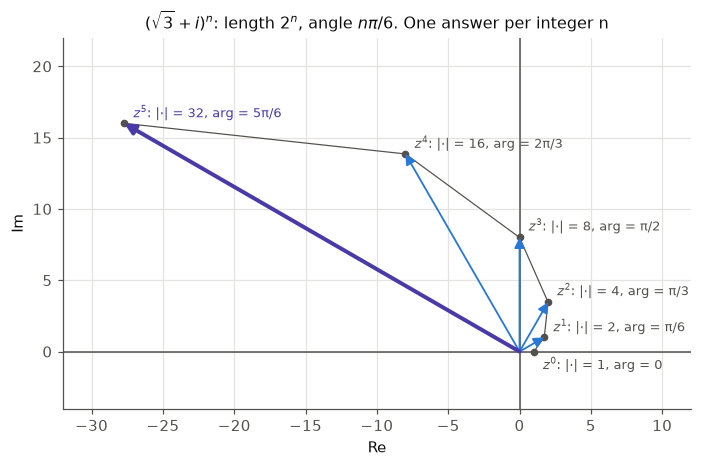

In [3]:
z = np.sqrt(3) + 1j
print("direct      :", np.round(z**5, 9))
print("De Moivre   :", np.round(32*(np.cos(5*np.pi/6) + 1j*np.sin(5*np.pi/6)), 9))
print("16(−√3 + i) :", np.round(16*(-np.sqrt(3) + 1j), 9))

# Picture (extra): each multiplication by z = 2 cis(π/6) doubles the length and adds 30°
P = z**np.arange(0, 6)
fig, ax = plt.subplots(figsize=(6.6, 5.6))
ax.axhline(0, color=INK2, lw=1); ax.axvline(0, color=INK2, lw=1); ax.set_aspect("equal")
ax.plot(P.real, P.imag, "o-", color=INK2, lw=0.8, ms=4)
for k, p in enumerate(P):
    if k: arrow(ax, 0, p, VIOLET if k == 5 else BLUE, 2.6 if k == 5 else 1.2)
    ax.annotate(f"$z^{k}$: |·| = {abs(p):.0f}, arg = {pi_str(np.angle(p))}", (p.real, p.imag), xytext=(6, -12 if k == 0 else 4),
                textcoords="offset points", fontsize=8.5, color=VIOLET if k == 5 else INK2)
ax.set_xlim(-32, 12); ax.set_ylim(-4, 22); ax.set_xlabel("Re"); ax.set_ylabel("Im")
ax.set_title(r"$(\sqrt{3}+i)^n$: length $2^n$, angle $n\pi/6$. One answer per integer n", fontsize=10.5)
plt.tight_layout(); plt.show()

---
## 3. Fractional Power: All Five Values of $(\sqrt3 + i)^{1/5}$

The denominator is $5$, so there are **5 answers**. Here is the lecturer's **4-step recipe**:

| Step | What to do | Here |
|---|---|---|
| 1 | Convert to **polar form** | $\sqrt3 + i = 2\left(\cos\frac{\pi}{6} + i\sin\frac{\pi}{6}\right)$ |
| 2 | **Add $2k\pi$ to the argument** (allowed because $\cos(2k\pi + \theta) = \cos\theta$ and $\sin(2k\pi + \theta) = \sin\theta$) | $2\left[\cos\left(2k\pi + \frac{\pi}{6}\right) + i\sin\left(2k\pi + \frac{\pi}{6}\right)\right]$ |
| 3 | **Apply De Moivre**: the power multiplies the whole argument | $2^{1/5}\left[\cos\dfrac{2k\pi + \frac{\pi}{6}}{5} + i\sin\dfrac{2k\pi + \frac{\pi}{6}}{5}\right] = 2^{1/5}\operatorname{cis}\dfrac{(12k + 1)\pi}{30}$ |
| 4 | Put in **consecutive** integers $k = 0, 1, \dots, q - 1$, as many as the denominator | $k = 0, 1, 2, 3, 4$ |

$$\boxed{(\sqrt3 + i)^{1/5} = 2^{1/5}\operatorname{cis}\frac{\pi}{30},\;\; 2^{1/5}\operatorname{cis}\frac{13\pi}{30},\;\; 2^{1/5}\operatorname{cis}\frac{25\pi}{30},\;\; 2^{1/5}\operatorname{cis}\frac{37\pi}{30},\;\; 2^{1/5}\operatorname{cis}\frac{49\pi}{30}}$$

**Why only 5?** Try $k = 5$: the angle is $\frac{61\pi}{30} = \frac{\pi}{30} + 2\pi$, the **same** as $k = 0$. $k = 6$ repeats $k = 1$, and so on. Any 5 consecutive integers give the 5 distinct answers, and starting from $k = 0$ is simplest.

> **Why step 2 matters:** without the $2k\pi$, step 3 gives only the single value $2^{1/5}\operatorname{cis}\frac{\pi}{30}$, which is part (b) of the theorem, "one of the values". The $2k\pi$ is what releases the other four.

In [4]:
roots5 = [2**0.2*np.exp(1j*(2*k*np.pi + np.pi/6)/5) for k in range(5)]
for k, w in enumerate(roots5):
    print(f"k = {k}:  angle = {pi_str((2*k*np.pi + np.pi/6)/5):>7}   w = {w:.4f}   w⁵ = {np.round(w**5, 9)}")
w5 = 2**0.2*np.exp(1j*(2*5*np.pi + np.pi/6)/5)
print(f"k = 5 repeats k = 0? {np.isclose(w5, roots5[0])}")
print("numpy: roots of w⁵ − (√3 + i):", np.round(np.sort_complex(np.roots([1, 0, 0, 0, 0, -(np.sqrt(3) + 1j)])), 4))

k = 0:  angle =    π/30   w = 1.1424+0.1201j   w⁵ = (1.732050808+1j)
k = 1:  angle =  13π/30   w = 0.2388+1.1236j   w⁵ = (1.732050808+1j)
k = 2:  angle =    5π/6   w = -0.9948+0.5743j   w⁵ = (1.732050808+1j)
k = 3:  angle =  37π/30   w = -0.8536-0.7686j   w⁵ = (1.732050808+1j)
k = 4:  angle =  49π/30   w = 0.4672-1.0494j   w⁵ = (1.732050808+1j)
k = 5 repeats k = 0? True
numpy: roots of w⁵ − (√3 + i): [-0.9948+0.5743j -0.8536-0.7686j  0.2388+1.1236j  0.4672-1.0494j
  1.1424+0.1201j]


### Animation *(extra)*: five different numbers, one fifth power
All five answers lie on a circle of radius $2^{1/5} \approx 1.149$, spaced $\frac{2\pi}{5} = 72°$ apart.

In the animation, $w$ glides from one answer to the next (left). Meanwhile $w^5$ (right) moves **five times as fast in angle**, so a $72°$ step in $w$ is a full $360°$ turn for $w^5$. That brings it back to $\sqrt3 + i$ every time $w$ reaches the next root. That's exactly why there are 5 fifth roots and not more.

In [5]:
target = np.sqrt(3) + 1j; R = 2**0.2; base = np.pi/30
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2), dpi=72)
ax = axes[0]; argand(ax, lim=1.6, ticks=0.5); circle(ax, R, color=AQUA, ls="--")
pent = np.array(roots5 + [roots5[0]]); ax.plot(pent.real, pent.imag, color=VIOLET, lw=1, alpha=0.5)
for k, r in enumerate(roots5):
    ax.plot(r.real, r.imag, "o", color=ORANGE, ms=9, mec="white", zorder=5)
    ax.text(r.real*1.15 - 0.1, r.imag*1.15 - 0.05, f"k={k}", color=ORANGE, fontsize=9.5, weight="bold")
ax.set_title(r"w moves along $|w| = 2^{1/5}$", fontsize=10.5)
v0, = ax.plot([], [], color=BLUE, lw=2.6); d0, = ax.plot([], [], "o", color=BLUE, ms=8)
ax2 = axes[1]; argand(ax2, lim=2.6); circle(ax2, 2, color=GRID)
ax2.plot(target.real, target.imag, "*", color=ORANGE, ms=18, zorder=5); ax2.text(target.real + 0.1, target.imag + 0.15, "√3 + i", color=ORANGE, weight="bold")
v1, = ax2.plot([], [], color=AQUA, lw=2.6); d1, = ax2.plot([], [], "o", color=AQUA, ms=8); tr, = ax2.plot([], [], color=AQUA, lw=1, alpha=0.4)
msg = ax2.text(-2.5, -2.45, "", fontsize=10, family="monospace")
ax2.set_title(r"$w^5$ turns 5× as fast and hits $\sqrt{3}+i$ at every root", fontsize=10.5)
per = 9; N = 5*per
def update(f):
    t = base + 2*np.pi*f/N; w_ = R*np.exp(1j*t); p = w_**5
    v0.set_data([0, w_.real], [0, w_.imag]); d0.set_data([w_.real], [w_.imag])
    v1.set_data([0, p.real], [0, p.imag]); d1.set_data([p.real], [p.imag])
    tt = np.linspace(5*base, 5*t, 300); tr.set_data(2*np.cos(tt), 2*np.sin(tt))
    at = f % per == 0
    msg.set_text(f"w = root k={f // per}  →  w⁵ = √3 + i" if at else f"arg w = {np.degrees(t):5.1f}°  arg w⁵ = {np.degrees(5*t) % 360:5.1f}°")
    return v0, d0, v1, d1, tr, msg
anim = animation.FuncAnimation(fig, update, frames=N, interval=90, blit=True)
plt.close(fig)
HTML(anim.to_jshtml(default_mode="loop"))

---
## 4. $n$-th Roots of Unity

Apply the same recipe to $1^{1/n}$, with $n \ge 2$ a natural number.

**Step 1: polar form.** $1 = \cos0 + i\sin0$.

**Step 2: add $2k\pi$.** $1 = \cos2k\pi + i\sin2k\pi$.

**Step 3: De Moivre.**
$$1^{1/n} = \cos\frac{2k\pi}{n} + i\sin\frac{2k\pi}{n} = e^{i\,2k\pi/n}$$
**Step 4: $k = 0, 1, \dots, n - 1$**, which gives $n$ values:
$$\boxed{1^{1/n} = 1,\; e^{i\,2\pi/n},\; e^{i\,4\pi/n},\; \dots,\; e^{i\,2(n-1)\pi/n}}$$
These are the **$n$-th roots of unity**.

**Notation.** Let $\alpha = e^{i\,2\pi/n}$. Then $e^{i\,4\pi/n} = \alpha^2$, and so on, so the roots are
$$1,\ \alpha,\ \alpha^2,\ \dots,\ \alpha^{n-1} \qquad\text{(also written } 1, \alpha_1, \alpha_2, \dots, \alpha_{n-1}\text{)}$$
For $n = 3$, $\alpha = \omega$, which recovers Lecture 7.

**Same thing, different words:** "the $n$-th roots of unity" = "the $n$ solutions of $x^n = 1$" = "the $n$ roots of the polynomial equation $x^n - 1 = 0$".

In [6]:
for n in [2, 3, 4, 5, 6, 8]:
    R_ = unity_roots(n)
    print(f"n = {n}: args = " + ", ".join(pi_str(2*np.pi*k/n) for k in range(n)) + f"   all satisfy xⁿ = 1: {np.allclose(R_**n, 1)}")

n = 2: args = 0, π   all satisfy xⁿ = 1: True
n = 3: args = 0, 2π/3, 4π/3   all satisfy xⁿ = 1: True
n = 4: args = 0, π/2, π, 3π/2   all satisfy xⁿ = 1: True
n = 5: args = 0, 2π/5, 4π/5, 6π/5, 8π/5   all satisfy xⁿ = 1: True
n = 6: args = 0, π/3, 2π/3, π, 4π/3, 5π/3   all satisfy xⁿ = 1: True
n = 8: args = 0, π/4, π/2, 3π/4, π, 5π/4, 3π/2, 7π/4   all satisfy xⁿ = 1: True


---
## 5. Properties of the $n$-th Roots of Unity

Let the roots be $1, \alpha, \alpha^2, \dots, \alpha^{n-1}$ with $\alpha = e^{i\,2\pi/n}$.

### Property 1: GP, with arguments in AP
The roots are in **geometric progression** with common ratio $\alpha = e^{i\,2\pi/n}$. Their arguments $0, \frac{2\pi}{n}, \frac{4\pi}{n}, \dots$ are in **arithmetic progression** with common difference $\frac{2\pi}{n}$.

### Property 2: the sum of all $n$ roots is $0$
$$1 + \alpha + \alpha^2 + \cdots + \alpha^{n-1} = 0$$
*Lecture's proof:* write the equation with every power showing:
$$x^n + 0\cdot x^{n-1} + 0\cdot x^{n-2} + \cdots - 1 = 0$$
The sum of roots of a polynomial is $-\frac{\text{coefficient of } x^{n-1}}{\text{coefficient of } x^n} = -\frac{0}{1} = 0$.

*(Another way, extra: it's a GP sum, $\frac{1 - \alpha^n}{1 - \alpha} = \frac{1 - 1}{1 - \alpha} = 0$.)*

### Property 3: every root to the power $n$ is $1$
$$\alpha_k^n = 1 \quad\text{for every root}$$
Each root satisfies $x^n - 1 = 0$, by definition.

### Property 4: unit circle, regular $n$-gon
Every root has modulus $1$, so all lie on the **unit circle** centred at the origin. Consecutive roots are $\frac{2\pi}{n}$ apart, so joining them in order gives a **regular $n$-sided polygon**:
- $n = 3$ gives an equilateral triangle
- $n = 4$ gives a square
- $n = 5$ gives a regular pentagon
- and so on

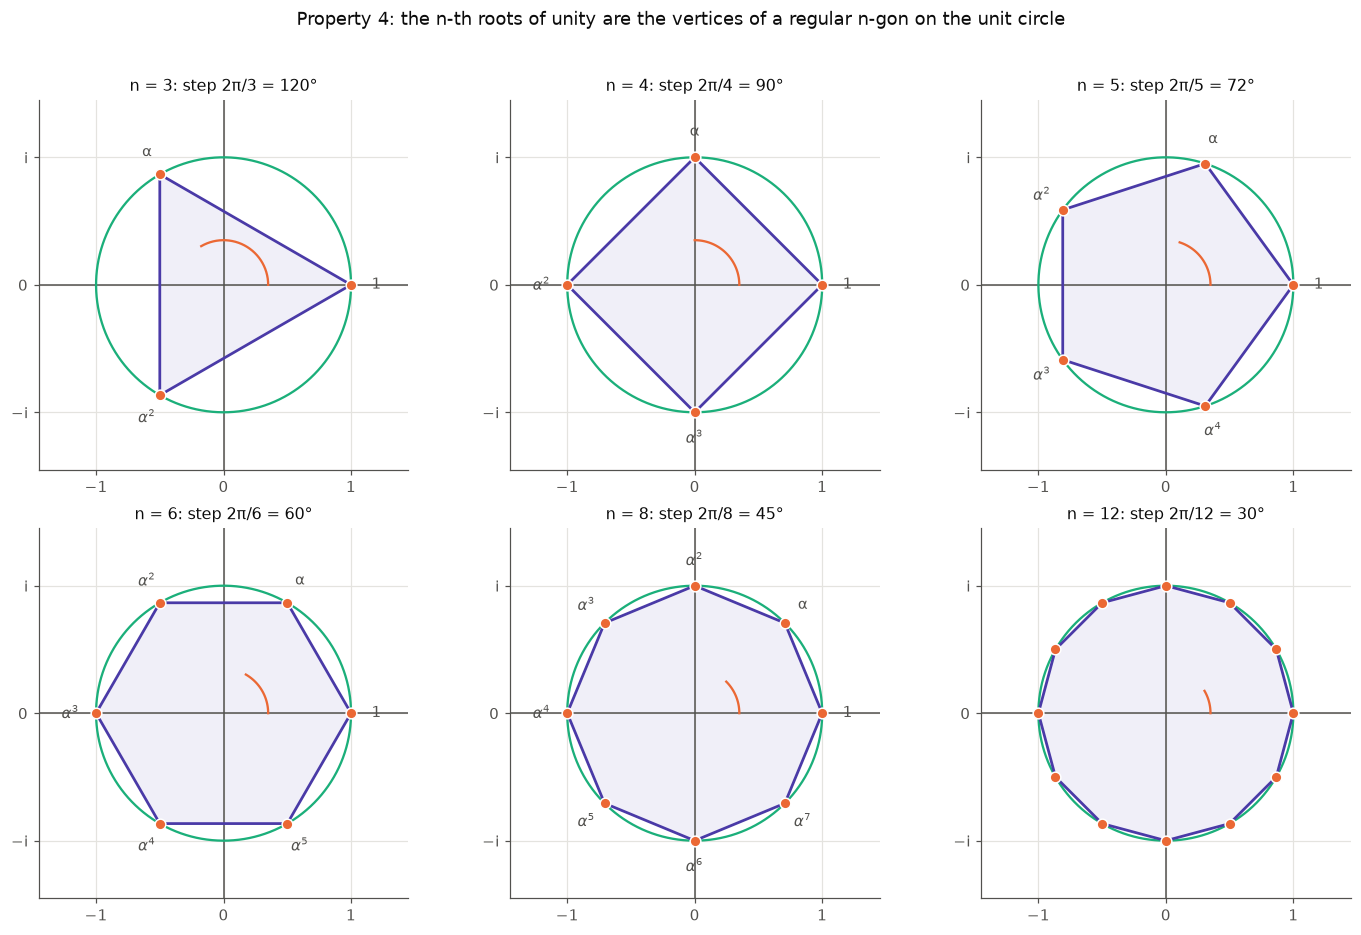

In [7]:
ns = [3, 4, 5, 6, 8, 12]
fig, axes = plt.subplots(2, 3, figsize=(13, 8.6))
for ax, n in zip(axes.ravel(), ns):
    argand(ax, lim=1.45); circle(ax, 1, color=AQUA); ax.set_xlabel(""); ax.set_ylabel("")
    R_ = unity_roots(n)
    ax.fill(R_.real, R_.imag, color=VIOLET, alpha=0.08); ax.plot(np.r_[R_.real, R_.real[0]], np.r_[R_.imag, R_.imag[0]], color=VIOLET, lw=1.8)
    for k, r in enumerate(R_):
        ax.plot(r.real, r.imag, "o", color=ORANGE, ms=7, mec="white", zorder=5)
        if n <= 8:
            lab = "1" if k == 0 else ("α" if k == 1 else f"$\\alpha^{{{k}}}$")
            ax.text(r.real*1.2, r.imag*1.2, lab, color=INK2, fontsize=9.5, ha="center", va="center")
    t = np.linspace(0, 2*np.pi/n, 30); ax.plot(0.35*np.cos(t), 0.35*np.sin(t), color=ORANGE, lw=1.5)
    ax.set_title(f"n = {n}: step 2π/{n} = {360/n:g}°", fontsize=10.5)
fig.suptitle("Property 4: the n-th roots of unity are the vertices of a regular n-gon on the unit circle", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

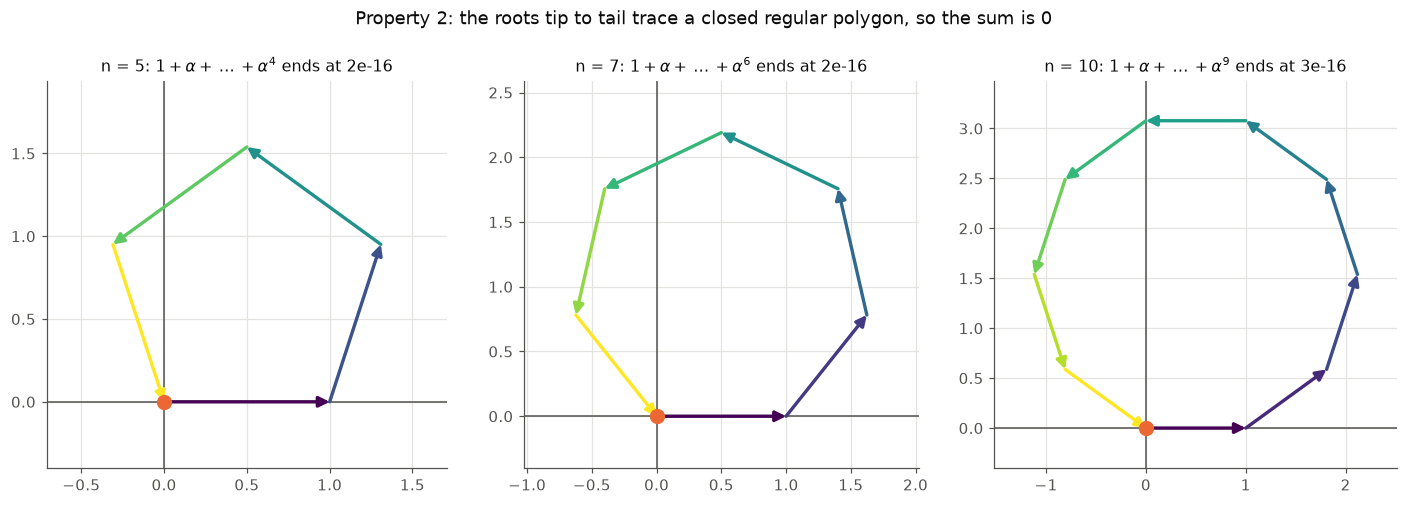

n =   2: sum of roots = 0j   all |αₖ| = 1: True
n =   3: sum of roots = 0j   all |αₖ| = 1: True
n =   5: sum of roots = 0j   all |αₖ| = 1: True
n =   7: sum of roots = 0j   all |αₖ| = 1: True
n =  10: sum of roots = 0j   all |αₖ| = 1: True
n = 100: sum of roots = 0j   all |αₖ| = 1: True


In [8]:
# Property 2 (picture): the n roots placed tip to tail close up, so their sum is 0
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, n in zip(axes, [5, 7, 10]):
    R_ = unity_roots(n); path = np.r_[0, np.cumsum(R_)]
    ax.axhline(0, color=INK2, lw=1); ax.axvline(0, color=INK2, lw=1); ax.set_aspect("equal")
    pad = 0.4; ax.set_xlim(path.real.min() - pad, path.real.max() + pad); ax.set_ylim(path.imag.min() - pad, path.imag.max() + pad)
    cmap = plt.get_cmap("viridis")
    for k in range(n):
        arrow(ax, path[k], path[k + 1], cmap(k/(n - 1)), 2.2)
    ax.plot(0, 0, "o", color=ORANGE, ms=9, zorder=6)
    ax.set_title(f"n = {n}: $1 + \\alpha + \\dots + \\alpha^{{{n-1}}}$ ends at {abs(path[-1]):.0e}", fontsize=10.5)
fig.suptitle("Property 2: the roots tip to tail trace a closed regular polygon, so the sum is 0", fontsize=11.5)
plt.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()
for n in [2, 3, 5, 7, 10, 100]:
    print(f"n = {n:>3}: sum of roots = {np.round(unity_roots(n).sum(), 12) + 0}   all |αₖ| = 1: {np.allclose(abs(unity_roots(n)), 1)}")

### Property 5: sum of $p$-th powers is $n$ or $0$
Just like $1 + \omega^p + \omega^{2p}$ in Lecture 7:
$$1 + \alpha^p + \alpha^{2p} + \cdots + \alpha^{(n-1)p} = \begin{cases} n, & p \text{ a multiple of } n \quad(\text{every term} = 1)\\[2pt] 0, & p \text{ an integer, not a multiple of } n\end{cases}$$

*Reason:* if $n \mid p$, each $\alpha_k^p = (\alpha_k^n)^{p/n} = 1$, so the sum is $n$. Otherwise $\alpha^p \ne 1$, and the sum is a GP: $\frac{1 - (\alpha^p)^n}{1 - \alpha^p} = \frac{1 - 1}{1 - \alpha^p} = 0$.

The animation steps $p$ through $0, 1, \dots, 8$ for $n = 6$. Tip to tail, the six terms close into a polygon (sum $0$) **unless** $p$ is a multiple of $6$, when they all line up along $+1$ (sum $6$).

In [9]:
n = 6; R6 = unity_roots(n)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), dpi=72, gridspec_kw=dict(width_ratios=[1.3, 1]))
ax = axes[0]; ax.set_xlim(-2.2, 6.6); ax.set_ylim(-2.4, 2.4); ax.set_aspect("equal"); ax.axhline(0, color=INK2, lw=1); ax.axvline(0, color=INK2, lw=1)
ax.plot(6, 0, "*", color=ORANGE, ms=14); ax.text(5.8, 0.25, "6", color=ORANGE, weight="bold")
cm = plt.get_cmap("viridis"); segs = [ax.plot([], [], color=cm(k/5), lw=2.8)[0] for k in range(n)]
ttl = ax.set_title("", fontsize=10.5)
ax2 = axes[1]; P = np.arange(0, 9)
S = [np.round((R6**p).sum().real, 9) + 0 for p in P]
bars = ax2.bar(P, [0]*len(P), color=[ORANGE if p % n == 0 else BLUE for p in P])
ax2.set_ylim(0, 7); ax2.set_xticks(P); ax2.set_xlabel("p"); ax2.set_ylabel("Σ αₖᵖ")
ax2.set_title("sum of p-th powers: 6 when 6 | p, else 0", fontsize=10.5)
per = 6; frames = len(P)*per
def update(f):
    p = P[f // per]; grow = min(1, (f % per + 1)/(per*0.55)); pos = 0j
    for k in range(n):
        term = R6[k]**p; frac = min(1, max(0, n*grow - k))
        end = pos + term*frac; segs[k].set_data([pos.real, end.real], [pos.imag, end.imag]); pos += term
    ttl.set_text(f"n = 6, p = {p}:  1 + α^{p} + α^{2*p} + … = {S[f // per]:.0f}")
    for j, b in enumerate(bars): b.set_height(S[j] if j <= f // per else 0)
    return (*segs, ttl, *bars)
anim = animation.FuncAnimation(fig, update, frames=frames, interval=110, blit=False)
plt.close(fig)
HTML(anim.to_jshtml(default_mode="loop"))

### Property 6: factorisation and the product of the roots
**Factor theorem:** if $x = a$ is a root of a polynomial, then $(x - a)$ is a factor. For example, $x = 1$ is a root of $x^3 - 1$, so $(x - 1)$ is a factor.

All $n$ roots of $x^n - 1$ are known, so all its factors are known:
$$\boxed{x^n - 1 = (x - 1)(x - \alpha)(x - \alpha^2)\cdots(x - \alpha^{n-1})}$$
Divide both sides by $(x - 1)$. The left side is a GP sum: $\frac{x^n - 1}{x - 1} = 1 + x + x^2 + \cdots + x^{n-1}$. So
$$1 + x + x^2 + \cdots + x^{n-1} = (x - \alpha)(x - \alpha^2)\cdots(x - \alpha^{n-1}) \qquad (\star)$$

**Product of all roots** (put $x = 0$ in the full factorisation):
$$-1 = (-1)^n\cdot1\cdot\alpha\cdots\alpha^{n-1} \;\Longrightarrow\; \boxed{1\cdot\alpha\cdot\alpha^2\cdots\alpha^{n-1} = (-1)^{n-1}}$$
**Put $x = 1$ in $(\star)$:**
$$\boxed{(1 - \alpha)(1 - \alpha^2)\cdots(1 - \alpha^{n-1}) = n}$$
*(The lecturer notes you can also put $x = -1$ to get another relation. Try it: the left side becomes $1 - 1 + 1 - \cdots$.)*

**Summary of these two:**
- the **sum** of the $n$-th roots of unity is $0$;
- the **product** is $(-1)^{n-1}$.

### Picture *(extra)*: $\prod(1 - \alpha_k) = n$ is about chord lengths
$|1 - \alpha^k|$ is the **distance from the vertex $1$ to the vertex $\alpha^k$** of the regular $n$-gon. Taking moduli of the last result:
> In a regular $n$-gon inscribed in the unit circle, the product of the distances from one vertex to all the others is exactly $n$.

n =  3: product of roots = +1  ((−1)^(n−1) = +1)   ∏(1 − αᵏ), k ≥ 1 = 3
n =  4: product of roots = -1  ((−1)^(n−1) = -1)   ∏(1 − αᵏ), k ≥ 1 = 4
n =  5: product of roots = +1  ((−1)^(n−1) = +1)   ∏(1 − αᵏ), k ≥ 1 = 5
n =  6: product of roots = -1  ((−1)^(n−1) = -1)   ∏(1 − αᵏ), k ≥ 1 = 6
n =  7: product of roots = +1  ((−1)^(n−1) = +1)   ∏(1 − αᵏ), k ≥ 1 = 7
n = 10: product of roots = -1  ((−1)^(n−1) = -1)   ∏(1 − αᵏ), k ≥ 1 = 10

factorisation check, n = 7: True
(⋆) check, n = 7         : True
x = −1 in (⋆), n = 7     : ∏(−1 − αᵏ) = (1-0j)  = 1 − 1 + 1 − … = 1


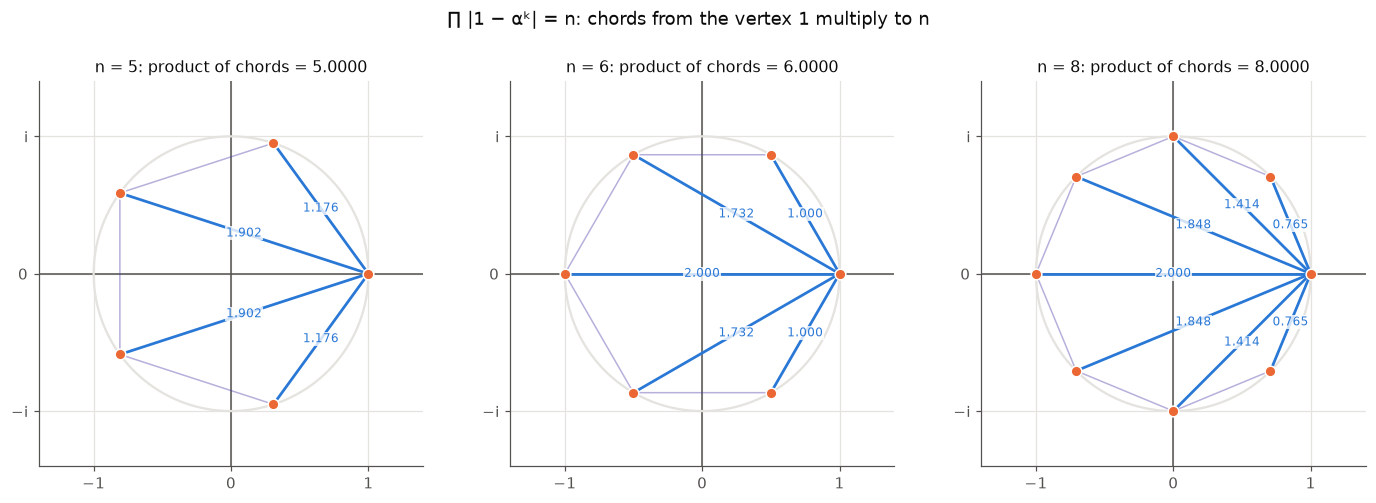

In [10]:
for n in [3, 4, 5, 6, 7, 10]:
    R_ = unity_roots(n)
    print(f"n = {n:>2}: product of roots = {np.round(R_.prod().real, 9) + 0:+.0f}  ((−1)^(n−1) = {(-1)**(n - 1):+d})"
          f"   ∏(1 − αᵏ), k ≥ 1 = {np.round(np.prod(1 - R_[1:]).real, 9) + 0:.0f}")
x = rng.normal(size=5) + 1j*rng.normal(size=5); n = 7; R_ = unity_roots(n)
print("\nfactorisation check, n = 7:", np.allclose(x**n - 1, np.prod([x - r for r in R_], axis=0)))
print("(⋆) check, n = 7         :", np.allclose(sum(x**k for k in range(n)), np.prod([x - r for r in R_[1:]], axis=0)))
print("x = −1 in (⋆), n = 7     : ∏(−1 − αᵏ) =", np.round(np.prod(-1 - R_[1:]), 9), " = 1 − 1 + 1 − … =", sum((-1)**k for k in range(n)))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, n in zip(axes, [5, 6, 8]):
    argand(ax, lim=1.4); circle(ax, 1, color=GRID); ax.set_xlabel(""); ax.set_ylabel("")
    R_ = unity_roots(n); ax.plot(np.r_[R_.real, R_.real[0]], np.r_[R_.imag, R_.imag[0]], color=VIOLET, lw=1, alpha=0.4)
    d = np.abs(1 - R_[1:])
    for r, L in zip(R_[1:], d):
        ax.plot([1, r.real], [0, r.imag], color=BLUE, lw=1.8)
        m = (1 + r)/2; ax.text(m.real, m.imag, f"{L:.3f}", fontsize=8, color=BLUE, ha="center", va="center",
                               bbox=dict(fc="white", ec="none", pad=0.5, alpha=0.8))
    ax.plot(R_.real, R_.imag, "o", color=ORANGE, ms=7, mec="white", zorder=5)
    ax.set_title(f"n = {n}: product of chords = {np.prod(d):.4f}", fontsize=10.5)
fig.suptitle("∏ |1 − αᵏ| = n: chords from the vertex 1 multiply to n", fontsize=11.5)
plt.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()

---
## Summary

| Idea | Result |
|---|---|
| De Moivre (integer $n$) | $(\cos\theta + i\sin\theta)^n = \cos n\theta + i\sin n\theta$, the **only** value |
| De Moivre (fraction $p/q$) | $q$ values. $\operatorname{cis}\frac{p\theta}{q}$ is just one of them |
| Recipe for $z^{p/q}$ | (1) polar form, (2) add $2k\pi$ to the argument, (3) power multiplies the argument, (4) $k = 0, 1, \dots, q - 1$ |
| Examples | $(\sqrt3 + i)^5 = 16(-\sqrt3 + i)$. $\;(\sqrt3 + i)^{1/5} = 2^{1/5}\operatorname{cis}\frac{(12k + 1)\pi}{30}$, $k = 0..4$ |
| $n$-th roots of unity | $e^{i2k\pi/n}$, $k = 0..n-1$, i.e. $1, \alpha, \dots, \alpha^{n-1}$ with $\alpha = e^{i2\pi/n}$ |
| GP / AP | ratio $\alpha$, arguments differ by $\frac{2\pi}{n}$ |
| Sum | $1 + \alpha + \cdots + \alpha^{n-1} = 0$ |
| Powers | $\alpha_k^n = 1$. $\;\sum_k\alpha_k^p = n$ if $n \mid p$, else $0$ |
| Geometry | unit circle, regular $n$-gon |
| Factorisation | $x^n - 1 = \prod_k(x - \alpha_k)$, $\;1 + x + \cdots + x^{n-1} = \prod_{k \ge 1}(x - \alpha_k)$ |
| Product | $\prod\alpha_k = (-1)^{n-1}$, $\;\prod_{k \ge 1}(1 - \alpha_k) = n$ |

The lecturer asks you to revise these notes two or three times and memorise every property, because JEE asks questions from this topic.

---
## Practice *(extra)*
1. Find all values of $(-8)^{1/3}$. *(Answer as $a + ib$.)*
2. Find all values of $i^{1/4}$ and plot them. What shape do they form?
3. Find $(1 + i)^{10}$ using De Moivre.
4. If $\alpha$ is a non-real 7th root of unity, find $(1 - \alpha)(1 - \alpha^2)\cdots(1 - \alpha^6)$ and $1 + \alpha^{14} + \alpha^{28} + \cdots + \alpha^{84}$.
5. Find the product of all the 5th roots of unity, and the sum of their squares.

<details>
<summary>Answers (open after attempting)</summary>

1. $-8 = 8\operatorname{cis}\pi$, so $(-8)^{1/3} = 2\operatorname{cis}\frac{(2k + 1)\pi}{3}$ for $k = 0, 1, 2$. These are $1 + \sqrt3 i$, $-2$, and $1 - \sqrt3 i$.
2. $i = \operatorname{cis}\frac{\pi}{2}$, so $i^{1/4} = \operatorname{cis}\frac{(4k + 1)\pi}{8}$ for $k = 0..3$. Four points $90°$ apart on the unit circle: a square.
3. $1 + i = \sqrt2\operatorname{cis}\frac{\pi}{4}$, so $(1 + i)^{10} = 32\operatorname{cis}\frac{10\pi}{4} = 32\operatorname{cis}\frac{\pi}{2} = 32i$.
4. $7$ (property 6). For the second: the terms are $(\alpha^{14})^j$ for $j = 0..6$, and $\alpha^{14} = (\alpha^7)^2 = 1$. So all 7 terms are $1$, giving $7$.
5. Product $= (-1)^{4} = 1$. Sum of squares $= 0$, since $p = 2$ is not a multiple of $5$.
</details>

In [11]:
# Checks for the practice set
r = [2*np.exp(1j*(2*k + 1)*np.pi/3) for k in range(3)]
print("1:", np.round(r, 6), "  cubes:", np.round([x**3 for x in r], 6))
r4 = [np.exp(1j*(4*k + 1)*np.pi/8) for k in range(4)]
print("2:", np.round(r4, 4), "  fourth powers:", np.round([x**4 for x in r4], 9), "  consecutive gaps (deg):", np.round(np.degrees(np.diff(np.angle(r4) % (2*np.pi))), 3))
print("3:", np.round((1 + 1j)**10, 9))
a = np.exp(2j*np.pi*3/7)
print("4:", np.round(np.prod([1 - a**k for k in range(1, 7)]), 9), "  ", np.round(sum(a**(14*j) for j in range(7)), 9))
R5 = unity_roots(5); print("5: product =", np.round(R5.prod(), 9) + 0, "  sum of squares =", np.round((R5**2).sum(), 9) + 0)

1: [ 1.+1.732051j -2.+0.j        1.-1.732051j]   cubes: [-8.+0.j -8.+0.j -8.-0.j]
2: [ 0.9239+0.3827j -0.3827+0.9239j -0.9239-0.3827j  0.3827-0.9239j]   fourth powers: [-0.+1.j  0.+1.j  0.+1.j -0.+1.j]   consecutive gaps (deg): [90. 90. 90.]
3: 32j
4: (7-0j)    (7-0j)
5: product = (1+0j)   sum of squares = 0j
